In [31]:
import os
import random
import time
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")
SEED = 46

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())

Random seed: 46
PyTorch version: 2.13.0
CUDA available: False
MPS available: True


In [33]:
DATA_DIR = "selected_500_species_dataset 2"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
TEST_DIR = os.path.join(DATA_DIR, "test")

TRAIN_CSV = os.path.join(DATA_DIR, "train_labels.csv")
VAL_CSV = os.path.join(DATA_DIR, "validation_labels.csv")
TEST_CSV = os.path.join(DATA_DIR, "test_labels.csv")

paths_to_check = {
    "Train directory": TRAIN_DIR,
    "Validation directory": VAL_DIR,
    "Test directory": TEST_DIR,
    "Train CSV": TRAIN_CSV,
    "Validation CSV": VAL_CSV,
    "Test CSV": TEST_CSV
}

for name, path in paths_to_check.items():
    print(f"{name}: {path}")
    print("Exists:", os.path.exists(path))
    print("-" * 50)

Train directory: selected_500_species_dataset 2/train
Exists: True
--------------------------------------------------
Validation directory: selected_500_species_dataset 2/val
Exists: True
--------------------------------------------------
Test directory: selected_500_species_dataset 2/test
Exists: True
--------------------------------------------------
Train CSV: selected_500_species_dataset 2/train_labels.csv
Exists: True
--------------------------------------------------
Validation CSV: selected_500_species_dataset 2/validation_labels.csv
Exists: True
--------------------------------------------------
Test CSV: selected_500_species_dataset 2/test_labels.csv
Exists: True
--------------------------------------------------


In [37]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(val_df.head())
display(test_df.head())

Train shape: (20000, 2)
Validation shape: (5000, 2)
Test shape: (5000, 2)


,file_name,category_id
0,6ad1b07b-71db-456d-96cc-33b51a1b1ab1.jpg,1251
1,c72c31a4-08ff-4fea-abfc-c3a9b8b4a911.jpg,1251
2,db469428-2dda-43ce-a807-339adc0f1bae.jpg,1251
3,e0ec6e01-488a-49a9-a93c-7553733bf0ef.jpg,1251
4,07244222-a31e-4e2f-bc0c-73f13117976d.jpg,1251


,file_name,category_id
0,e986c7a6-904c-4b09-971a-d97707a4b816.jpg,1251
1,50d9c86a-8053-4bfc-944d-d74e4bb5b436.jpg,1251
2,35fe1495-a579-4a4b-900a-3dc56ed11826.jpg,1251
3,041b2d3f-a101-4ea7-86aa-3f9cd09e9f30.jpg,1251
4,4fe1bdfa-133a-4e46-a289-2296b78e7389.jpg,1251


,file_name,category_id
0,6ba17b04-5e1d-40d2-b60a-183676f2ad9b.jpg,5813
1,200b87d5-ad48-48e1-a3d3-a721f0c3ec23.jpg,4943
2,935c569d-6b96-465b-9fcf-9e0970500766.jpg,2630
3,73db5011-71ea-4026-b3df-3768b6adeb41.jpg,1405
4,bc419462-91cb-4523-bf18-ed079efb0da6.jpg,3768


In [39]:
print("Train columns:", train_df.columns.tolist())
print("Validation columns:", val_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

print("Number of train classes:", train_df["category_id"].nunique())
print("Number of validation classes:", val_df["category_id"].nunique())
print("Number of test classes:", test_df["category_id"].nunique())

print("Train category sample:")
print(train_df["category_id"].head(10).tolist())

Train columns: ['file_name', 'category_id']
Validation columns: ['file_name', 'category_id']
Test columns: ['file_name', 'category_id']
Number of train classes: 500
Number of validation classes: 500
Number of test classes: 500
Train category sample:
[1251, 1251, 1251, 1251, 1251, 1251, 1251, 1251, 1251, 1251]


In [41]:
all_categories = sorted(train_df["category_id"].unique())

category_to_index = {
    category_id: index
    for index, category_id in enumerate(all_categories)
}

index_to_category = {
    index: category_id
    for category_id, index in category_to_index.items()
}

train_df["label"] = train_df["category_id"].map(category_to_index)
val_df["label"] = val_df["category_id"].map(category_to_index)
test_df["label"] = test_df["category_id"].map(category_to_index)

print("Number of mapped classes:", len(category_to_index))
print("Mapped label range:",
      train_df["label"].min(),
      "to",
      train_df["label"].max())

display(train_df.head())

Number of mapped classes: 500
Mapped label range: 0 to 499


,file_name,category_id,label
0,6ad1b07b-71db-456d-96cc-33b51a1b1ab1.jpg,1251,60
1,c72c31a4-08ff-4fea-abfc-c3a9b8b4a911.jpg,1251,60
2,db469428-2dda-43ce-a807-339adc0f1bae.jpg,1251,60
3,e0ec6e01-488a-49a9-a93c-7553733bf0ef.jpg,1251,60
4,07244222-a31e-4e2f-bc0c-73f13117976d.jpg,1251,60


In [43]:
train_categories = set(train_df["category_id"].unique())
val_categories = set(val_df["category_id"].unique())
test_categories = set(test_df["category_id"].unique())

print("Train and validation classes match:",
      train_categories == val_categories)

print("Train and test classes match:",
      train_categories == test_categories)

print("Missing labels in train:",
      train_df["label"].isna().sum())

print("Missing labels in validation:",
      val_df["label"].isna().sum())

print("Missing labels in test:",
      test_df["label"].isna().sum())

Train and validation classes match: True
Train and test classes match: True
Missing labels in train: 0
Missing labels in validation: 0
Missing labels in test: 0


In [45]:
class SpeciesDataset(Dataset):
    def __init__(self, dataframe, image_dirs, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)

        if isinstance(image_dirs, str):
            image_dirs = [image_dirs]

        self.image_dirs = image_dirs
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        file_name = row["file_name"]

        image_path = None

        for image_dir in self.image_dirs:
            candidate_path = os.path.join(image_dir, file_name)

            if os.path.exists(candidate_path):
                image_path = candidate_path
                break

        if image_path is None:
            raise FileNotFoundError(
                f"Image not found in configured directories: {file_name}"
            )

        image = Image.open(image_path).convert("RGB")
        label = int(row["label"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [47]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [49]:
train_dataset = SpeciesDataset(
    dataframe=train_df,
    image_dirs=[
        "selected_500_species_dataset/train",
        "selected_500_species_dataset 2/train"
    ],
    transform=train_transform
)

val_dataset = SpeciesDataset(
    dataframe=val_df,
    image_dirs="selected_500_species_dataset 2/val",
    transform=eval_transform
)

test_dataset = SpeciesDataset(
    dataframe=test_df,
    image_dirs="selected_500_species_dataset 2/test",
    transform=eval_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 20000
Validation dataset: 5000
Test dataset: 5000


In [53]:
sample_image, sample_label = train_dataset[0]

print("Image tensor shape:", sample_image.shape)
print("Mapped label:", sample_label)
print("Original category ID:", index_to_category[sample_label])

Image tensor shape: torch.Size([3, 224, 224])
Mapped label: 60
Original category ID: 1251


In [55]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 625
Validation batches: 157
Test batches: 157


In [12]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Label range:", labels.min().item(), "to", labels.max().item())

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Label range: 37 to 496


In [13]:
NUM_CLASSES = 500

def build_resnet18(pretrained=False, num_classes=NUM_CLASSES):
    if pretrained:
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
    else:
        model = models.resnet18(weights=None)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model

In [14]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: mps


In [15]:
NUM_CLASSES = 500

resnet_imagenet = build_resnet18(
    pretrained=True,
    num_classes=NUM_CLASSES
).to(device)

print(resnet_imagenet.fc)

Linear(in_features=512, out_features=500, bias=True)


In [16]:
model = resnet_imagenet.to(device)

sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    outputs = model(sample_images)

print("Input batch shape:", sample_images.shape)
print("Output shape:", outputs.shape)

Input batch shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 500])


In [64]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print(criterion)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [18]:
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

print(scheduler)

In [19]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [60]:
def evaluate(
    model,
    dataloader,
    criterion,
    device,
    max_wrong_examples=12
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    # 只保存有限数量的错误样本
    wrong_images = []
    wrong_true_labels = []
    wrong_pred_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # 保存一部分错误预测图片
            wrong_mask = predicted != labels
            wrong_indices = torch.where(wrong_mask)[0]

            for idx in wrong_indices:
                if len(wrong_images) >= max_wrong_examples:
                    break

                wrong_images.append(images[idx].cpu())
                wrong_true_labels.append(labels[idx].item())
                wrong_pred_labels.append(predicted[idx].item())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return (
        epoch_loss,
        epoch_acc,
        all_labels,
        all_predictions,
        wrong_images,
        wrong_true_labels,
        wrong_pred_labels
    )

In [21]:
NUM_EPOCHS = 10

train_losses = []
train_accs = []

val_losses = []
val_accs = []

best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step()

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_resnet18_ImageNet.pth"
        )

        print("Best ImageNet model saved.")


Epoch [1/10]
Train Loss : 5.0474
Train Acc  : 0.1340
Val Loss   : 3.7127
Val Acc    : 0.2998
Best ImageNet model saved.

Epoch [2/10]
Train Loss : 3.2230
Train Acc  : 0.3964
Val Loss   : 2.7925
Val Acc    : 0.4202
Best ImageNet model saved.

Epoch [3/10]
Train Loss : 2.3082
Train Acc  : 0.5498
Val Loss   : 2.2751
Val Acc    : 0.5010
Best ImageNet model saved.

Epoch [4/10]
Train Loss : 1.7401
Train Acc  : 0.6536
Val Loss   : 2.0753
Val Acc    : 0.5378
Best ImageNet model saved.

Epoch [5/10]
Train Loss : 1.3390
Train Acc  : 0.7332
Val Loss   : 1.9500
Val Acc    : 0.5504
Best ImageNet model saved.

Epoch [6/10]
Train Loss : 0.9176
Train Acc  : 0.8432
Val Loss   : 1.7805
Val Acc    : 0.6024
Best ImageNet model saved.

Epoch [7/10]
Train Loss : 0.8114
Train Acc  : 0.8704
Val Loss   : 1.7579
Val Acc    : 0.6048
Best ImageNet model saved.

Epoch [8/10]
Train Loss : 0.7514
Train Acc  : 0.8852
Val Loss   : 1.7441
Val Acc    : 0.6082
Best ImageNet model saved.

Epoch [9/10]
Train Loss : 0.712

In [22]:
model.load_state_dict(
    torch.load(
        "best_resnet18_ImageNet.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

print("Best ImageNet model loaded successfully.")

Best ImageNet model loaded successfully.


In [ ]:
(
    test_loss,
    test_acc,
    test_labels,
    test_preds,
    wrong_images,
    wrong_true_labels,
    wrong_pred_labels
) = evaluate(
    model,
    test_loader,
    criterion,
    device,
    max_wrong_examples=12
)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)
print("Saved wrong examples:", len(wrong_images))

In [24]:
print(classification_report(
    test_labels,
    test_preds,
    labels=list(range(NUM_CLASSES)),
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

           0     0.7000    0.7000    0.7000        10
           1     0.4167    0.5000    0.4545        10
           2     0.6000    0.3000    0.4000        10
           3     0.3846    0.5000    0.4348        10
           4     0.6154    0.8000    0.6957        10
           5     0.5714    0.8000    0.6667        10
           6     0.6364    0.7000    0.6667        10
           7     0.5556    0.5000    0.5263        10
           8     0.5000    0.4000    0.4444        10
           9     0.8889    0.8000    0.8421        10
          10     0.8000    0.8000    0.8000        10
          11     0.7000    0.7000    0.7000        10
          12     0.7273    0.8000    0.7619        10
          13     0.7778    0.7000    0.7368        10
          14     0.8889    0.8000    0.8421        10
          15     0.6667    0.6000    0.6316        10
          16     0.8750    0.7000    0.7778        10
          17     0.9000    

In [25]:
precision = precision_score(
    test_labels,
    test_preds,
    average="macro",
    zero_division=0
)

recall = recall_score(
    test_labels,
    test_preds,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    test_labels,
    test_preds,
    average="macro",
    zero_division=0
)

balanced_acc = balanced_accuracy_score(
    test_labels,
    test_preds
)

print(f"Test Accuracy      : {test_acc:.4f}")
print(f"Macro Precision    : {precision:.4f}")
print(f"Macro Recall       : {recall:.4f}")
print(f"Macro F1-score     : {macro_f1:.4f}")
print(f"Balanced Accuracy  : {balanced_acc:.4f}")

Test Accuracy      : 0.6090
Macro Precision    : 0.6252
Macro Recall       : 0.6090
Macro F1-score     : 0.6037
Balanced Accuracy  : 0.6090


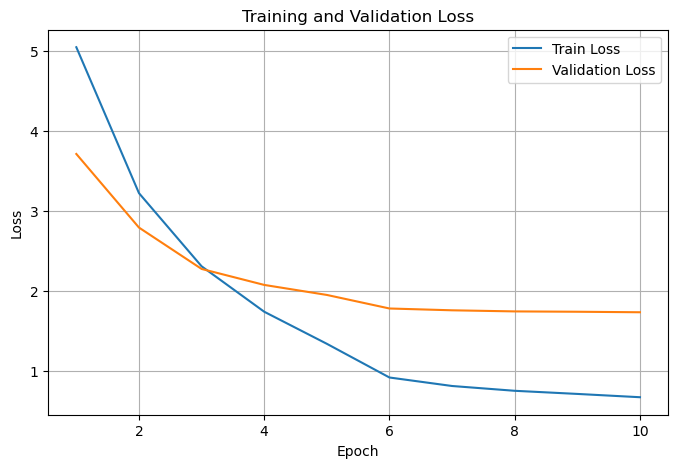

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

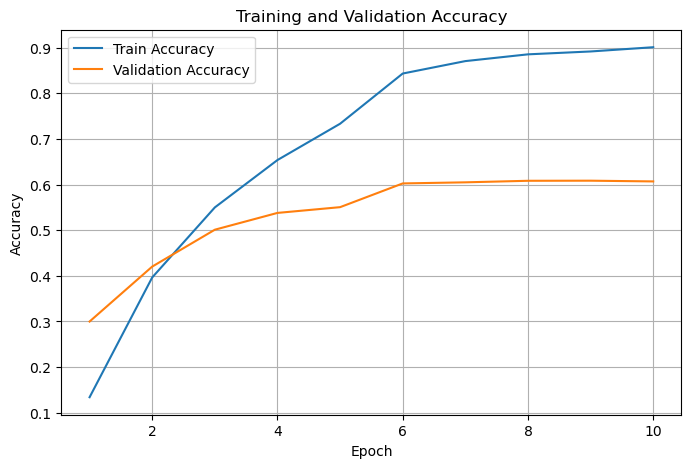

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_accs, label="Train Accuracy")
plt.plot(range(1, NUM_EPOCHS + 1), val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
def calculate_top5_accuracy(model, dataloader, device):
    model.eval()

    top5_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            top5_predictions = outputs.topk(
                k=5,
                dim=1
            ).indices

            top5_correct += (
                top5_predictions == labels.unsqueeze(1)
            ).any(dim=1).sum().item()

            total += labels.size(0)

    return top5_correct / total


test_top5_acc = calculate_top5_accuracy(
    model,
    test_loader,
    device
)

print(f"Top-1 Accuracy : {test_acc:.4f}")
print(f"Top-5 Accuracy : {test_top5_acc:.4f}")

Top-1 Accuracy : 0.6090
Top-5 Accuracy : 0.8214


In [29]:
start_time = time.time()

test_loss, test_acc, test_labels, test_preds = evaluate(
    model,
    test_loader,
    criterion,
    device
)

test_time = time.time() - start_time

print(f"Total test time: {test_time:.2f} seconds")
print(
    f"Average inference time per image: "
    f"{test_time / len(test_dataset):.6f} seconds"
)

Total test time: 29.10 seconds
Average inference time per image: 0.005821 seconds


In [30]:
cm = confusion_matrix(
    test_labels,
    test_preds,
    labels=list(range(NUM_CLASSES))
)

print("Confusion matrix shape:", cm.shape)
print("Total evaluated samples:", cm.sum())

Confusion matrix shape: (500, 500)
Total evaluated samples: 5000


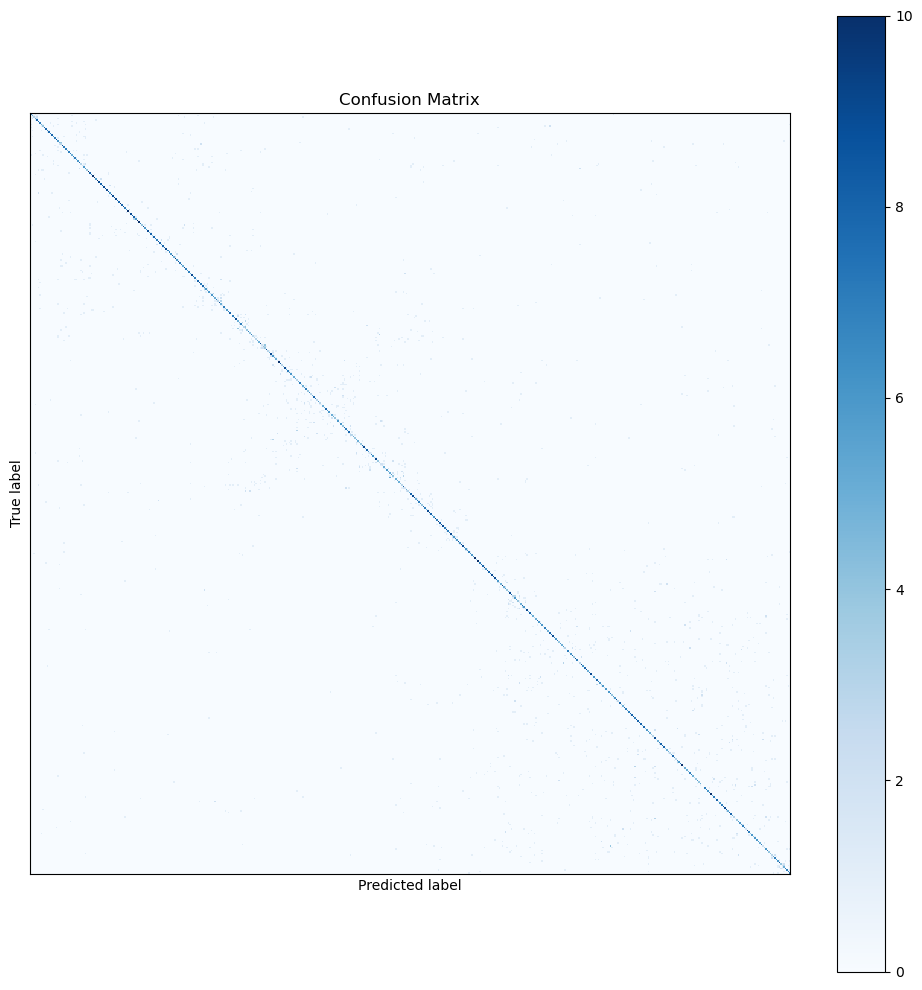

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(
    ax=ax,
    include_values=False,
    cmap="Blues",
    colorbar=True
)

ax.set_xticks([])
ax.set_yticks([])

plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix_imagenet.png", dpi=300)
plt.show()

In [70]:
import torch


def collect_wrong_predictions(
    model,
    dataloader,
    device,
    max_examples=12
):
    """
    Collect a limited number of misclassified examples.

    Returns:
        wrong_images: image tensors stored on CPU
        wrong_true_labels: true class indices
        wrong_pred_labels: predicted class indices
    """
    model.eval()

    wrong_images = []
    wrong_true_labels = []
    wrong_pred_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            wrong_indices = torch.where(predictions != labels)[0]

            for index in wrong_indices:
                wrong_images.append(images[index].cpu())
                wrong_true_labels.append(labels[index].item())
                wrong_pred_labels.append(predictions[index].item())

                if len(wrong_images) >= max_examples:
                    return (
                        wrong_images,
                        wrong_true_labels,
                        wrong_pred_labels
                    )

    return wrong_images, wrong_true_labels, wrong_pred_labels

In [72]:
wrong_images, wrong_true_labels, wrong_pred_labels = (
    collect_wrong_predictions(
        model=model,
        dataloader=test_loader,
        device=device,
        max_examples=12
    )
)

print("Collected wrong examples:", len(wrong_images))

Collected wrong examples: 12


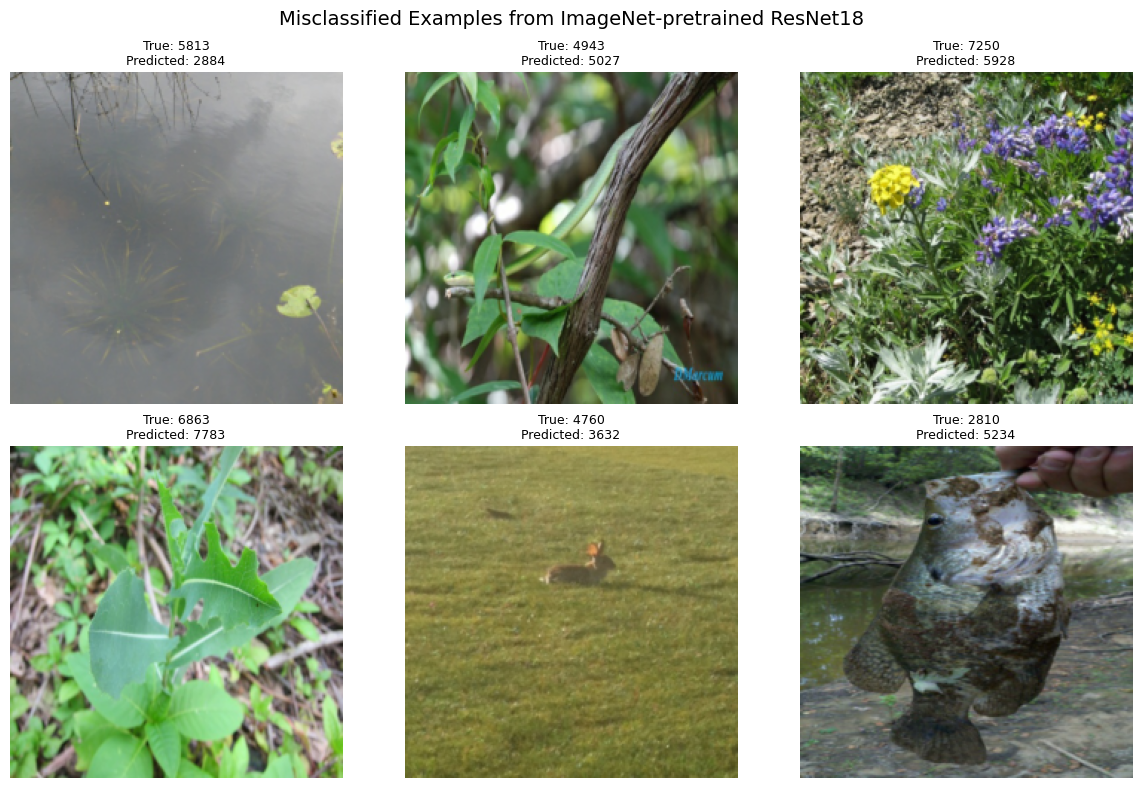

In [74]:
import numpy as np
import matplotlib.pyplot as plt

num_examples = min(6, len(wrong_images))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# ImageNet normalization parameters
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(num_examples):
    image = wrong_images[i].numpy().transpose(1, 2, 0)

    # Reverse normalization
    image = image * std + mean
    image = np.clip(image, 0, 1)

    true_label = wrong_true_labels[i]
    pred_label = wrong_pred_labels[i]

    true_name = index_to_category.get(true_label, true_label)
    pred_name = index_to_category.get(pred_label, pred_label)

    axes[i].imshow(image)
    axes[i].set_title(
        f"True: {true_name}\nPredicted: {pred_name}",
        fontsize=9
    )
    axes[i].axis("off")

for i in range(num_examples, len(axes)):
    axes[i].axis("off")

plt.suptitle(
    "Misclassified Examples from ImageNet-pretrained ResNet18",
    fontsize=14
)

plt.tight_layout()
plt.savefig(
    "misclassified_examples_imagenet.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()